In [24]:
from pyscf import gto, scf, cc
import numpy as np
from jax import numpy as jnp
from jax import vmap, jit
import jax
from functools import partial

atoms = '''
N        0.0000000000      0.0000000000      0.0000000000
N        2.1180000000      0.0000000000      0.0000000000
'''

frozen = 0

mol = gto.M(atom=atoms,
            basis='ccpvdz',
            spin=0,
            unit='B',
            verbose=4)
mol.build()

mf = scf.UHF(mol)
mf.kernel()

mo = mf.stability()[0]
dm = mf.make_rdm1(mo,mf.mo_occ)
mf.kernel(dm0=dm)
mo = mf.stability()[0]
dm = mf.make_rdm1(mo,mf.mo_occ)
mf.kernel(dm0=dm)


nfrozen = 2
mycc = cc.CCSD(mf,frozen=nfrozen)
mycc.kernel()[0]

et = mycc.ccsd_t()

System: uname_result(system='Linux', node='sharmagroup-rn', release='6.17.0-19-generic', version='#19~24.04.2-Ubuntu SMP PREEMPT_DYNAMIC Fri Mar  6 23:08:46 UTC 2', machine='x86_64')  Threads 16
Python 3.11.14 (main, Oct 21 2025, 18:31:21) [GCC 11.2.0]
numpy 2.3.1  scipy 1.16.2  h5py 3.14.0
Date: Thu Mar 19 19:57:49 2026
PySCF version 2.12.1
PySCF path  /home/sharmagroup/sharmagroup/pyscf
GIT ORIG_HEAD 3d1768f5e33b144b606c3d2c81c12ee54d794501
GIT HEAD (branch master) f0861da51f017364d8bbaa20b742a94f3733305f

[ENV] PYSCF_EXT_PATH /home/sharmagroup/sharmagroup/pyscf-forge
[CONFIG] conf_file None
[INPUT] verbose = 4
[INPUT] num. atoms = 2
[INPUT] num. electrons = 14
[INPUT] charge = 0
[INPUT] spin (= nelec alpha-beta = 2S) = 0
[INPUT] symmetry False subgroup None
[INPUT] Mole.unit = B
[INPUT] Symbol           X                Y                Z      unit          X                Y                Z       unit  Magmom
[INPUT]  1 N      0.000000000000   0.000000000000   0.000000000000 AA   

In [1]:
import numpy as np
from jax import numpy as jnp
data = np.load('/home/sharmagroup/sharmagroup/project/abs/n2/traject.npz')
t = data["time"]
wts = data["weights"]
ens = data["energies"]

In [2]:
ehf = -108.949377879015
efci = -109.27834
t0 = np.hstack([[0], t])
ntrj = wts.shape[1]
e_init = jnp.full((1, ntrj), ehf)
wt_init = jnp.full((1, ntrj), 200.)
ens0 = np.vstack([e_init, ens])
wts0 = np.vstack([wt_init, wts])
# print(ens_mod.shape)

In [3]:
wt_path = np.sum(wts0, axis=1)
mean = np.sum(ens0*wts0,axis=1)/wt_path
std = np.sqrt(np.sum(wts0 * (ens0 - mean[:,None])**2, axis=1) / wt_path) / np.sqrt(ntrj)
print(mean[20], std[20])

(-109.27943737780485-0.0037873432268869535j) (0.0019944100123490557+4.018242712977718e-05j)


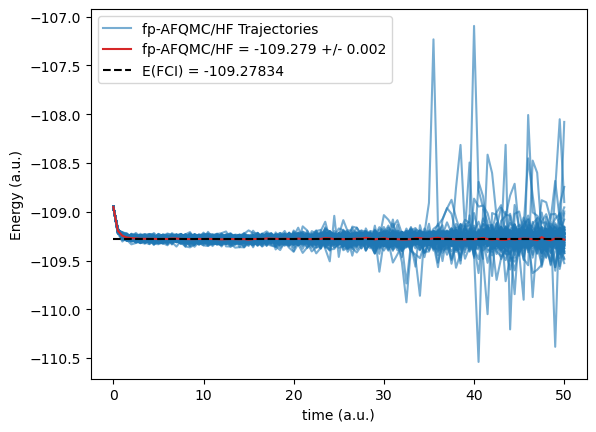

In [9]:
from matplotlib import pyplot as plt
plt.plot(t0, ens0[:,:1].real,'-',color="C0", alpha=0.6, label='fp-AFQMC/HF Trajectories')
plt.plot(t0, ens0[:,1:].real,'-',color="C0", alpha=0.6)
plt.plot(t0, mean.real, '-', color="C3", label=f'fp-AFQMC/HF = {mean[20].real:.3f} +/- {std[20].real:.3f}')
plt.plot(t0, [efci]*len(t0), '--',color='black', label=f'E(FCI) = {efci}')
plt.xlabel("time (a.u.)")
plt.ylabel("Energy (a.u.)")
plt.legend()
plt.show()

In [13]:
print(mean[20])
print(std[20])

(-109.28121737636197-0.00349044006578886j)
(0.0019446637872491273+5.551489614864629e-05j)


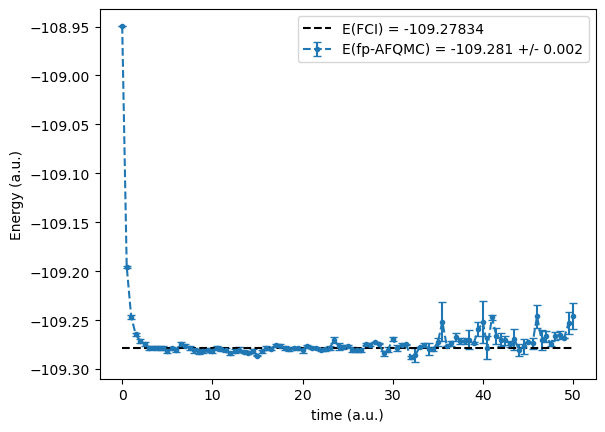

In [23]:
plt.errorbar(t0, mean.real, yerr=std.real, fmt='.--', capsize=3, color="C0", label=f'E(fp-AFQMC) = {mean[20].real:.3f} +/- {std[20].real:.3f}')
plt.plot(t0, [efci]*len(t0), '--',color='black',label=f'E(FCI) = {efci}')
plt.xlabel("time (a.u.)")
plt.ylabel("Energy (a.u.)")
plt.legend()
plt.show()

In [33]:
options = {'n_eql': 3,
           'n_prop_steps': 50,
            'n_ene_blocks': 1,
            'n_sr_blocks': 5,
            'n_blocks': 100,
            'n_walkers': 300,
            'seed': 2,
            'walker_type': 'uhf',
            'trial': 'uhf',
            'dt':0.005,
            'free_projection':False,
            'group': False,
            'ad_mode':None,
            'use_gpu': False,
            }

from ad_afqmc.prop_unrestricted import prep
import jax
jax.config.update("jax_enable_x64", True)
prep.prep_afqmc(mycc,chol_cut=1e-6)
# prop_unrestricted.run_afqmc(options,nproc=1)
option_file='options.bin'
import pickle
with open(option_file, 'wb') as f:
    pickle.dump(options, f)

#
# Preparing AFQMC calculation
# Calculating Cholesky integrals
# Finished calculating Cholesky integrals
#
# Size of the correlation space:
# Number of electrons: (5, 5)
# Number of basis functions: 26
# Number of Cholesky vectors: 207
#


In [34]:
import time
import numpy as np
from jax import random
from jax import numpy as jnp
from functools import partial 

ham_data, ham, prop, trial, wave_data, sampler, options = (prep._prep_afqmc())

init_time = time.time()

### initialize propagation
init_walkers = None
trial_rdm1 = trial.get_rdm1(wave_data)
if "rdm1" not in wave_data:
    wave_data["rdm1"] = trial_rdm1
ham_data = ham.build_measurement_intermediates(ham_data, trial, wave_data)
ham_data = ham.build_propagation_intermediates(ham_data, prop, trial, wave_data)

prop_data = prop.init_prop_data(trial, wave_data, ham_data, init_walkers)
if jnp.abs(jnp.sum(prop_data["overlaps"])) < 1.0e-6:
    raise ValueError(
        "Initial overlaps are zero. Pass walkers with non-zero overlap."
    )
prop_data["key"] = random.PRNGKey(options["seed"])

prop_data["overlaps"] = trial.calc_overlap(prop_data["walkers"], wave_data)
prop_data["n_killed_walkers"] = 0

e_init= jnp.real(trial.calc_energy(prop_data["walkers"], ham_data, wave_data)[0])
prop_data["e_estimate"] = e_init
prop_data["pop_control_ene_shift"] = prop_data["e_estimate"]

print(e_init)
print(e_init-mf.e_tot)

# norb: 26
# nelec: (5, 5)
# n_eql: 3
# n_prop_steps: 50
# n_ene_blocks: 1
# n_sr_blocks: 5
# n_blocks: 100
# n_walkers: 300
# seed: 2
# walker_type: uhf
# trial: uhf
# dt: 0.005
# free_projection: False
# group: False
# use_gpu: False
# n_exp_terms: 6
# symmetry: False
# save_walkers: False
# fp_abs: False
# n_batch: 1
# max_error: 0.001
-108.94937928146152
-1.4024439281001833e-06


In [35]:
wt_sp = np.zeros(sampler.n_blocks,dtype="float64")
e_sp = np.zeros(sampler.n_blocks,dtype="float64")

block_time = prop.dt * sampler.n_prop_steps * sampler.n_ene_blocks * sampler.n_sr_blocks

for n in range(sampler.n_blocks):
    prop_data, (wt, e) \
        = sampler.propagate_phaseless(prop_data, ham_data, prop, trial, wave_data)
    
    wt_sp[n] = wt
    e_sp[n] = e

    if n > 20 :
        weight = np.sum(wt_sp[20:n+1])
        energy = np.sum(wt_sp[20:n+1] * e_sp[20:n+1]) / weight
        error = np.sqrt(np.sum(wt_sp[:n+1] * (e_sp[:n+1] - energy)**2) / weight) / np.sqrt(n)

        prop_data["e_estimate"] = 0.9 * prop_data["e_estimate"] + 0.1 * energy

        print(f"   {n*block_time:.2f} \t {energy:.6f} \t {error:.6f} \t {time.time() - init_time:.2f} ")
    else:
        prop_data["e_estimate"] = 0.9 * prop_data["e_estimate"] + 0.1 * e
        print(f"   {n*block_time:.2f} \t {e:.6f} \t ------ \t {time.time() - init_time:.2f} ")

   0.00 	 -109.220260 	 ------ 	 62.72 
   1.25 	 -109.257738 	 ------ 	 65.91 
   2.50 	 -109.260950 	 ------ 	 67.43 
   3.75 	 -109.272115 	 ------ 	 68.95 
   5.00 	 -109.261515 	 ------ 	 70.47 
   6.25 	 -109.280208 	 ------ 	 71.99 
   7.50 	 -109.266827 	 ------ 	 73.52 
   8.75 	 -109.278266 	 ------ 	 75.04 
   10.00 	 -109.289982 	 ------ 	 76.56 
   11.25 	 -109.270307 	 ------ 	 78.08 
   12.50 	 -109.318267 	 ------ 	 79.61 
   13.75 	 -109.279376 	 ------ 	 81.13 
   15.00 	 -109.278335 	 ------ 	 82.65 
   16.25 	 -109.298492 	 ------ 	 84.18 
   17.50 	 -109.296298 	 ------ 	 85.70 
   18.75 	 -109.261367 	 ------ 	 87.22 
   20.00 	 -109.292536 	 ------ 	 88.75 
   21.25 	 -109.277290 	 ------ 	 90.27 
   22.50 	 -109.283941 	 ------ 	 91.79 
   23.75 	 -109.299303 	 ------ 	 93.32 
   25.00 	 -109.296486 	 ------ 	 94.84 
   26.25 	 -109.282492 	 0.014679 	 96.36 
   27.50 	 -109.273391 	 0.011841 	 97.89 
   28.75 	 -109.269710 	 0.010552 	 99.41 
   30.00 	 -109.27

In [38]:
np.arange(sampler.n_blocks)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99])

In [39]:
atom_time = block_time*(np.arange(sampler.n_blocks+1))


In [41]:
mf.e_tot

np.float64(-108.94937787901759)

In [42]:
print(wt_sp.shape)
print(e_sp.shape)
e_sp = np.hstack(([mf.e_tot], e_sp))

(100,)
(100,)


In [45]:
wt_sp = np.hstack(([300*5], wt_sp))
print(wt_sp.shape)

(101,)


In [43]:
print(e_sp.shape)

(101,)


In [61]:
n = len(atom_time)
weight = np.sum(wt_sp[20:])
energy = np.sum(wt_sp[20:] * e_sp[20:]) / weight
error = np.sqrt(np.sum(wt_sp[20:] * (e_sp[20:] - energy)**2) / weight) / np.sqrt(n-20)
print(energy)
print(error)

-109.27998175899636
0.0016288901771313999


In [57]:
atom_time[12]

np.float64(15.0)

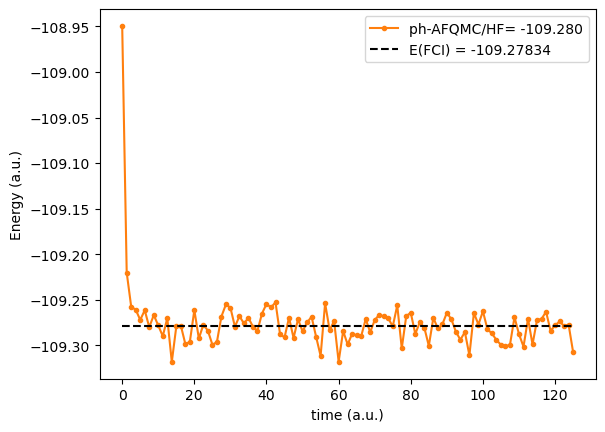

In [65]:
plt.plot(atom_time, e_sp, '.-', color = 'C1', label=f'ph-AFQMC/HF= {energy:.3f}')
# plt.plot(atom_time, [energy]*len(atom_time), '--',color='red',label=f'ph-AFQMC/HF = {energy:.3f}')
plt.plot(atom_time, [efci]*len(atom_time), '--',color='black',label=f'E(FCI) = {efci}')
plt.xlabel("time (a.u.)")
plt.ylabel("Energy (a.u.)")
plt.legend()
plt.show()